In [1]:
import os
import re
import pickle
from dataclasses import dataclass
from typing import Iterable, List, Dict, Set

import numpy as np

from tqdm import tqdm

from utils import ViTSplit, EarlyStopping, cer_metric
from models.transformers import TransformerEncoder, TransformerDecoder
from modelInference.inference_utils import ModelInference

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

import datasets
from datasets import load_from_disk, concatenate_datasets

from transformers import PreTrainedTokenizerFast
from tokenizers import Tokenizer, models, trainers, normalizers, pre_tokenizers, processors, Regex

In [2]:
torch.cuda.is_available()

True

In [3]:
DATASET_PATH = os.getenv("datasetPath")
ARTIFACTS_PATH = os.getenv("artifactsPath")
IMG_FOLDER_PATH = os.getenv("imgFolderPath")

In [4]:
main_dataset = load_from_disk(DATASET_PATH)

In [5]:
train_set = concatenate_datasets([main_dataset["train"], main_dataset["test"]])
val_set = main_dataset["valid"]
print(f"Training length: {len(train_set)}")
print(f"Validation length: {len(val_set)}")

Training length: 9397
Validation length: 976


In [6]:
small_emotion = datasets.Dataset.from_dict(train_set[:2])
small_emotion

Dataset({
    features: ['text', 'image'],
    num_rows: 2
})

In [7]:
type(train_set["image"][10])

PIL.JpegImagePlugin.JpegImageFile

In [8]:
class CharTokenizer:
    def __init__(self, iterable: Iterable[str]):
        self.iterable = iterable
        self.max_len = None
        self.fast_tokenizer = None
        self.tokenizer = None
    
    def get_max_len(self) -> int:
        """Returns the max length of encoded sequences"""
        assert self.fast_tokenizer != None, "Tokenizer is not trained"
        if self.max_len is None:
            the_max = 0
            for string in self.iterable["text"]:
                encoded = self.fast_tokenizer(string)["input_ids"]
                the_max = max(the_max, len(encoded))
            self.max_len = the_max
            return self.max_len
        else:
            return self.max_len

    def train(self) -> None:
        """Train tokenizer character wise"""
        tokenizer = Tokenizer(model = models.WordLevel())
        tokenizer.normalizer = normalizers.Sequence([normalizers.Lowercase(),
                                                     normalizers.Replace(Regex(r"[^a-z0-9\s]"), r""),
                                                     normalizers.Replace(Regex(r"\s+"), r" "),
                                                     normalizers.Strip()])
        
        tokenizer.pre_tokenizer = pre_tokenizers.Split(r"", "isolated", invert=False)
        tokenizer.post_processor = processors.TemplateProcessing(single=r"<sos> $0 <eos>",
                                                                 special_tokens=[(r"<sos>", 2), (r"<eos>", 3)])

        trainer = trainers.WordLevelTrainer(special_tokens=["<pad>", "<unk>", "<sos>", "<eos>"])
        tokenizer.train_from_iterator(iterator=self.iterable["text"], trainer=trainer)

        self.tokenizer = tokenizer
        self.fast_tokenizer = PreTrainedTokenizerFast(tokenizer_object = tokenizer)
        self.fast_tokenizer.pad_token = "<pad>"

In [9]:
with open(ARTIFACTS_PATH+r"\\char_tokenizer_obj.pkl", r"rb") as tokenizer_pickle_file:
    tokenizer = pickle.load(tokenizer_pickle_file)
tokenizer

In [10]:
with open(ARTIFACTS_PATH+r"\\statistics_dict.pkl", r"rb") as statistics_pickle_file:
    statistics = pickle.load(statistics_pickle_file)
statistics

{'mean': 0.9136844277381897, 'std': 0.14744582772254944}

In [11]:
input_ids = tokenizer.fast_tokenizer('Wherever you go, there you are', padding='max_length', max_length=tokenizer.get_max_len())["input_ids"]
len(input_ids)

86

In [12]:
input_ids[:20]

[2, 20, 13, 5, 12, 5, 25, 5, 12, 4, 23, 8, 17, 4, 21, 8, 4, 6, 13, 5]

In [13]:
tokenizer.fast_tokenizer.decode(input_ids, skip_special_tokens=True)

'w h e r e v e r   y o u   g o   t h e r e   y o u   a r e'

In [14]:
ViTSplit(pic_size=(1, 128, 256), split_size=4)

In [15]:
class TrainDataSet(Dataset):
    def __init__(self, dataset: datasets.arrow_dataset.Dataset,
                 tokenizer: CharTokenizer,
                 transformations: transforms.transforms.Compose,
                 split: ViTSplit):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.transforms = transformations
        self.split = split
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, indx):
        row = self.dataset[indx]
        img = self.transforms(row["image"])
        splitted_img = self.split(img)
        target_inds = self.tokenizer.fast_tokenizer(row["text"],
                                                    padding='max_length',
                                                    max_length=self.tokenizer.get_max_len())["input_ids"]
        tensor_target_ids = torch.tensor(target_inds, dtype=torch.long)
        y = tensor_target_ids.clone()
        y[y==3] = 0
        z = torch.cat([tensor_target_ids.clone()[1:], torch.tensor([self.tokenizer.fast_tokenizer.pad_token_type_id], dtype=torch.long)], dim=0)
        # We concatenate the strips of an image
        x = torch.cat(splitted_img, dim=0)
        return x, y, z

In [16]:
class ValDataSet(TrainDataSet):
    def __init__(self, dataset: datasets.arrow_dataset.Dataset,
                 tokenizer: CharTokenizer,
                 transformations: transforms.transforms.Compose,
                 split: ViTSplit):
        super().__init__(dataset, tokenizer, transformations, split)
        
    def __getitem__(self, indx):
        row = self.dataset[indx]
        img = row["image"]
        target_inds = self.tokenizer.fast_tokenizer(row["text"],
                                                    padding='max_length',
                                                    max_length=self.tokenizer.get_max_len())["input_ids"]
        decoded_text = self.tokenizer.fast_tokenizer.decode(target_inds, skip_special_tokens = True)
        return img, decoded_text

In [17]:
pytorch_train_set = TrainDataSet(dataset=train_set,
                         tokenizer=tokenizer,
                         transformations=transforms.Compose([transforms.ToTensor(),
                                                             transforms.Resize((128, 256)),
                                                             transforms.Normalize(mean=(statistics["mean"], ), std=(statistics["std"], ))]),
                        split=ViTSplit(pic_size=(1, 128, 256), split_size=4))

In [18]:
pytorch_small_set = TrainDataSet(dataset=small_emotion,
                                 tokenizer=tokenizer,
                                 transformations=transforms.Compose([transforms.ToTensor(),
                                                                     transforms.Resize((128, 256)),
                                                                     transforms.Normalize(mean=(statistics["mean"], ), std=(statistics["std"], ))]),
                                                                     split=ViTSplit(pic_size=(1, 128, 256), split_size=4))

In [19]:
pytorch_val_set = ValDataSet(dataset=val_set,
                             tokenizer=tokenizer,
                             transformations=transforms.Compose([transforms.ToTensor(),
                                                                 transforms.Resize((128, 256)),
                                                                 transforms.Normalize(mean=(statistics["mean"], ), std=(statistics["std"], ))]),
                                                                 split=ViTSplit(pic_size=(1, 128, 256), split_size=4))

In [45]:
pytorch_small_val_set = ValDataSet(dataset=small_emotion,
                                   tokenizer=tokenizer,
                                   transformations=transforms.Compose([transforms.ToTensor(),
                                                                       transforms.Resize((128, 256)),
                                                                       transforms.Normalize(mean=(statistics["mean"], ), std=(statistics["std"], ))]),
                                                                       split=ViTSplit(pic_size=(1, 128, 256), split_size=4))

In [20]:
print(f"Type of picture: {type(pytorch_val_set[0][0])}")
print(f"Length of validation set: {len(pytorch_val_set)}", end='\n\n')
print("Example of validation text:")
print(pytorch_val_set[1][1])

Type of picture: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Length of validation set: 976

Example of validation text:
s y m p a t h e t i c   c   o   p a u l   d a n e m a n   g a v e   a n o t h e r


In [21]:
print(f"Big dataset length: {len(pytorch_train_set)}")
print(f"Small dataset length: {len(pytorch_small_set)}")

Big dataset length: 9397
Small dataset length: 2


In [22]:
print(f"Vocabulary size: {pytorch_train_set.tokenizer.fast_tokenizer.vocab_size}")

Vocabulary size: 41


In [23]:
@dataclass
class TrainConfig:
    # Training specifications
    lr: float = 0.005
    batch_size: int = 2
    dropout: float = 0.35
    # Dataset specifications
    pad_idx: int = 0
    strip_dim: int = 512
    vocab_size: int = 41
    max_seq_length_encoder: int = 64
    max_seq_length_decoder: int = 86
    # Blocks specifications
    num_layers: int = 3
    d_model: int = 512
    d_feedforward: int = 1024
    h: int = 4

In [24]:
config = TrainConfig()
config

TrainConfig(lr=0.005, batch_size=2, dropout=0.35, pad_idx=0, strip_dim=512, vocab_size=41, max_seq_length_encoder=64, max_seq_length_decoder=86, num_layers=3, d_model=512, d_feedforward=1024, h=4)

In [25]:
input_ids_y = pytorch_train_set[957][1]
input_ids_z = pytorch_train_set[957][2]

In [26]:
print(f"Max sequence length: {len(input_ids_y)}")
print(input_ids_y)

Max sequence length: 86
tensor([ 2, 21,  8, 25,  5, 12,  9, 18,  5,  9,  6,  4, 11, 17, 21, 21,  5, 11,
         6, 11,  4,  6, 13,  7,  6,  4,  7, 14, 14,  4, 10, 11,  4,  9,  8,  6,
         4, 20,  5, 14, 14,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])


In [27]:
print(input_ids_z)

tensor([21,  8, 25,  5, 12,  9, 18,  5,  9,  6,  4, 11, 17, 21, 21,  5, 11,  6,
        11,  4,  6, 13,  7,  6,  4,  7, 14, 14,  4, 10, 11,  4,  9,  8,  6,  4,
        20,  5, 14, 14,  3,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])


In [28]:
pytorch_train_set.tokenizer.fast_tokenizer.decode(input_ids_y, skip_special_tokens=False)

'<sos> g o v e r n m e n t   s u g g e s t s   t h a t   a l l   i s   n o t   w e l l <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>'

In [29]:
pytorch_train_set.tokenizer.fast_tokenizer.decode(input_ids_z, skip_special_tokens=False)

'g o v e r n m e n t   s u g g e s t s   t h a t   a l l   i s   n o t   w e l l <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>'

In [30]:
loader = DataLoader(dataset=pytorch_train_set, shuffle=True, batch_size=2)
sample = next(iter(loader))

In [31]:
print(f"Type of sample: {type(sample)}")
print(f"Length of sample list: {len(sample)}")
print(f"Splitted pictures shape: {sample[0].shape}")

Type of sample: <class 'list'>
Length of sample list: 3
Splitted pictures shape: torch.Size([2, 64, 128, 4])


In [32]:
class ViTEncoder(TransformerEncoder):
    def __init__(self, strip_dim: int, max_seq_len: int, d_model: int, d_feedforward: int, 
                 h: int, num_layers: int, pad_idx: int = 0, dropout:float = 0.35):
            super().__init__(strip_dim, max_seq_len, d_model, d_feedforward, 
                 h, num_layers, pad_idx, dropout)
            self.token_embed = nn.Linear(strip_dim, d_model)

In [33]:
class ViTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten_layer = nn.Flatten(start_dim=-2, end_dim=-1)
        self.encoder = ViTEncoder(strip_dim = config.strip_dim,
                                  max_seq_len = config.max_seq_length_encoder,
                                  d_model = config.d_model,
                                  d_feedforward = config.d_feedforward,
                                  h = config.h,
                                  num_layers = config.num_layers,
                                  pad_idx = config.pad_idx,
                                  dropout = config.dropout)
        self.decoder = TransformerDecoder(vocab_size = config.vocab_size,
                                          max_seq_len = config.max_seq_length_decoder,
                                          d_model = config.d_model,
                                          d_feedforward = config.d_feedforward,
                                          h = config.h,
                                          num_layers = config.num_layers,
                                          dropout = config.dropout,
                                          mask=True,
                                          mask_device='cuda')
        self.linear = nn.Linear(config.d_model, config.vocab_size)
    def forward(self, x: torch.tensor, y: torch.tensor):
        """
        Arguments
        ---------
        x: torch.tensor
            Tensor of shape B x N x H x W_strip of stripped image
        """
        x = self.flatten_layer(x)
        # return y
        x = self.encoder(x)
        x = self.decoder(y, x_dec=x)
        x = self.linear(x)
        return x

In [34]:
sample[0].shape

torch.Size([2, 64, 128, 4])

In [35]:
@dataclass
class TrainConfig:
    # Training specifications
    lr: float = 4e-5
    batch_size: int = 2
    dropout: float = 0.35
    # Dataset specifications
    pad_idx: int = 0
    strip_dim: int = 512
    vocab_size: int = 41
    max_seq_length_encoder: int = 64
    max_seq_length_decoder: int = 86
    # Blocks specifications
    num_layers: int = 3
    d_model: int = 512
    d_feedforward: int = 1024
    h: int = 4

config = TrainConfig()
config

TrainConfig(lr=4e-05, batch_size=2, dropout=0.35, pad_idx=0, strip_dim=512, vocab_size=41, max_seq_length_encoder=64, max_seq_length_decoder=86, num_layers=3, d_model=512, d_feedforward=1024, h=4)

In [36]:
vit_model = ViTModel()
vit_model.to(device='cuda')

dataloader = DataLoader(dataset=pytorch_small_set, batch_size=config.batch_size, shuffle=True)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params=vit_model.parameters(), lr=config.lr)
device = 'cuda'

In [37]:
def train_epoch(
    model: torch.nn.Module,
    dataloader: DataLoader,
    criterion: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device
) -> List[float]:
    """Execute one training epoch."""
    model.train()
    loss_list = []
    
    for inputs_x, inputs_y, targets in tqdm(dataloader, desc="Going through the dataset"):
        inputs_x, inputs_y, targets = inputs_x.to(device), inputs_y.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs_x, inputs_y).flatten(start_dim=0, end_dim=1)
        targets = targets.flatten()
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        loss_value = round(loss.detach().item(), 5)
        loss_list.append(loss_value)
    return loss_list

In [53]:
def validate(model: nn.Module, val_dataset: Dataset, max_seq_length: int):
    model.eval()
    inference = ModelInference(model = model,
                               tokenizer = val_dataset.tokenizer.fast_tokenizer,
                               split = ViTSplit(pic_size=(1, 128, 256), split_size=4),
                               max_seq_length=max_seq_length,
                               transformations = transforms.Compose([transforms.ToTensor(),
                                                                     transforms.Resize((128, 256)),
                                                                     transforms.Normalize(mean=(statistics["mean"], ), std=(statistics["std"], ))]))
    
    accuracy_scores = []
    for val_item in tqdm(val_dataset, desc='Going through validation dataset...'):
        prediction = inference.generate(val_item[0])
        accuracy = 1 - cer_metric(gt=val_item[1], pred=prediction)
        accuracy_scores.append(accuracy)
    rounded_result = round(np.array(accuracy_scores).mean().item(), 5)
    return rounded_result

In [39]:
def train_model(
    model: torch.nn.Module,
    train_loader: DataLoader,
    criterion: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    num_epochs: int,
    device: torch.device,
) -> Dict[str, list]:
    """Main training loop."""
    avg_epoch_loss = []
    avg_val_accuracy = []
    
    for epoch_ind in range(num_epochs):
        # Training
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        mean_loss = np.array(train_loss).mean()
        avg_epoch_loss.append(mean_loss)
        print(f"Epoch #{epoch_ind+1}")
        print(mean_loss)
    
    return avg_epoch_loss

In [40]:
result = train_model(
    model = vit_model,
    train_loader = dataloader,
    criterion = criterion,
    optimizer = optimizer,
    num_epochs = 1000,
    device = device
)

Going through the dataset: 100%|██████████| 1/1 [00:00<00:00,  3.34it/s]


Epoch #1
3.99453


Going through the dataset: 100%|██████████| 1/1 [00:00<00:00, 10.76it/s]


Epoch #2
2.95886


Going through the dataset: 100%|██████████| 1/1 [00:00<00:00, 10.92it/s]


...

Epoch #72
0.45256


Going through the dataset: 100%|██████████| 1/1 [00:00<00:00, 10.00it/s]


Epoch #73
0.45722


Going through the dataset:   0%|          | 0/1 [00:00<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# torch.save(vit_model.state_dict(), r"C:\main\GitHub\model_weights\vit_model_small_dataset_overfit.pth")

In [42]:
vit_model.load_state_dict(torch.load(r"C:\main\GitHub\model_weights\vit_model_small_dataset_overfit.pth"))

<All keys matched successfully>

In [43]:
vit_model.to(device='cpu')

ViTModel(
  (flatten_layer): Flatten(start_dim=-2, end_dim=-1)
  (encoder): ViTEncoder(
    (token_embed): Linear(in_features=512, out_features=512, bias=True)
    (pos_embed): Embedding(64, 512)
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (mha): MultiHeadAttention(
          (heads_dict): ModuleDict(
            (head_0): ModuleDict(
              (q): Linear(in_features=512, out_features=512, bias=True)
              (k): Linear(in_features=512, out_features=512, bias=True)
              (v): Linear(in_features=512, out_features=512, bias=True)
            )
            (head_1): ModuleDict(
              (q): Linear(in_features=512, out_features=512, bias=True)
              (k): Linear(in_features=512, out_features=512, bias=True)
              (v): Linear(in_features=512, out_features=512, bias=True)
            )
            (head_2): ModuleDict(
              (q): Linear(in_features=512, out_features=512, bias=True)
              (k): Linear(in_fe

In [54]:
# Test validation function
validate(vit_model, val_dataset=pytorch_small_val_set, max_seq_length=config.max_seq_length_decoder)

Going through validation dataset...: 100%|██████████| 2/2 [00:01<00:00,  1.40it/s]


0.98462

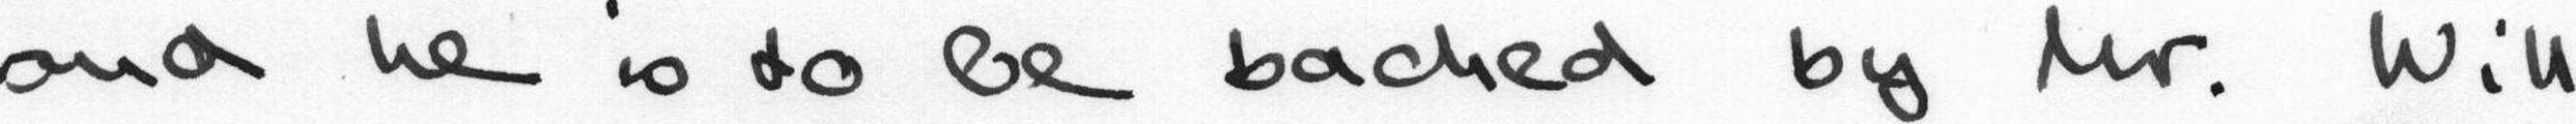

In [ ]:
picture = small_emotion['image'][1]
picture

In [ ]:
from modelInference.inference_utils import ModelInference

In [ ]:
vit_model.to(device='cpu')

ViTModel(
  (flatten_layer): Flatten(start_dim=-2, end_dim=-1)
  (encoder): ViTEncoder(
    (token_embed): Linear(in_features=512, out_features=512, bias=True)
    (pos_embed): Embedding(64, 512)
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (mha): MultiHeadAttention(
          (heads_dict): ModuleDict(
            (head_0): ModuleDict(
              (q): Linear(in_features=512, out_features=512, bias=True)
              (k): Linear(in_features=512, out_features=512, bias=True)
              (v): Linear(in_features=512, out_features=512, bias=True)
            )
            (head_1): ModuleDict(
              (q): Linear(in_features=512, out_features=512, bias=True)
              (k): Linear(in_features=512, out_features=512, bias=True)
              (v): Linear(in_features=512, out_features=512, bias=True)
            )
            (head_2): ModuleDict(
              (q): Linear(in_features=512, out_features=512, bias=True)
              (k): Linear(in_fe

In [ ]:
for decoder_layer in vit_model.decoder.layers:
    decoder_layer.mask = decoder_layer.mask.to(device='cpu')

In [ ]:
for decoder_layer in vit_model.decoder.layers:
    value = decoder_layer.mask.device
    print(value)

cpu
cpu
cpu


In [ ]:
inf = ModelInference(model = vit_model,
                     tokenizer=pytorch_train_set.tokenizer.fast_tokenizer,
                     transformations = transforms.Compose([transforms.ToTensor(),
                                                                     transforms.Resize((128, 256)),
                                                                     transforms.Normalize(mean=(statistics["mean"], ), std=(statistics["std"], ))]),
                     split = ViTSplit(pic_size=(1, 128, 256), split_size=4)
                     )

In [ ]:
gen_values = inf.generate(picture)
gen_values

'a n d   h e   i s   t o   b e   b a c k e d   b y   m r   w i l'

In [ ]:
early_stopping = EarlyStopping(patience = 2)

In [ ]:
early_stopping.add(0.2)
early_stopping.should_stop()

False

In [ ]:
early_stopping.add(0.35)
early_stopping.should_stop()

False

In [ ]:
early_stopping.add(0.2)
early_stopping.should_stop()

False

In [ ]:
early_stopping.add(0.15)
early_stopping.should_stop()

True